# MAna Modeling Module

`MAna.modeling` is the model-building and model-management layer of MAna. It
contains helpers for:

- quick preprocessing utilities,
- classification, regression, and clustering evaluation,
- cross-validation and feature importance,
- automatic model selection and hyperparameter search,
- model registry/versioning and sklearn persistence,
- optional Keras callbacks and model saving,
- PyTorch training utilities and simple neural networks,
- modeling visualizations.

The notebook uses real datasets:

- Women's clothing reviews for a binary classification problem.
- Dubai electricity demand for a regression problem.
- Movie metadata for clustering and unsupervised diagnostics.

Deep-learning sections are guarded so the notebook can run even when optional
GPU/deep-learning stacks are not the focus of the current environment.

## 1. Setup

The default path uses scikit-learn models because they are fast, transparent,
and enough to exercise the modeling utilities end-to-end.

In [1]:
from pathlib import Path
import importlib.util
import tempfile
import warnings

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from MAna.data import DataCleaner, read_data
from MAna.modeling import (
    EvaluationReport,
    ModelMetadata,
    ModelRegistry,
    PyTorchTrainer,
    PyTorchTrainingHistory,
    SimpleClassifier,
    SimpleRegressor,
    accuracy_pytorch,
    aggregate_data,
    auto_classifier,
    auto_regressor,
    calculate_rolling_average,
    confusion_matrix as mana_confusion_matrix,
    count_parameters,
    create_data_loaders,
    cross_validate_model,
    evaluate,
    evaluate_classification,
    evaluate_clustering,
    evaluate_regression,
    f1_score_pytorch,
    freeze_layers,
    get_device,
    get_training_callbacks,
    hyperparameter_search,
    load_keras_model,
    load_pytorch_model,
    load_sklearn_model,
    loss_plot,
    model_checkpoint,
    plot_classification_report,
    plot_cluster,
    plot_elbow,
    plot_feature_importance,
    plot_pca,
    plot_predictions_vs_actual,
    plot_residuals,
    precision_recall_curve as mana_precision_recall_curve,
    roc_curve as mana_roc_curve,
    save_keras_model,
    save_pytorch_model,
    save_sklearn_model,
    set_seed,
    silhouette,
    unfreeze_layers,
)

pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("data")
if not DATA_DIR.exists():
    DATA_DIR = Path("docs/notebooks/data")
REVIEWS_PATH = DATA_DIR / "womens_clothing_reviews_sample.csv"
ELECTRICITY_PATH = DATA_DIR / "electricity_load_q3.csv"
MOVIE_CATALOG_PATH = DATA_DIR / "movielens_movie_catalog.csv"

TORCH_AVAILABLE = importlib.util.find_spec("torch") is not None
TENSORFLOW_AVAILABLE = importlib.util.find_spec("tensorflow") is not None

## 2. Load and Prepare Real Modeling Data

The examples use MAna's data module first, then switch into modeling.

In [2]:
reviews_raw = read_data(REVIEWS_PATH)
electricity_raw = read_data(ELECTRICITY_PATH)
movies_raw = read_data(MOVIE_CATALOG_PATH)

{
    "reviews": reviews_raw.shape,
    "electricity": electricity_raw.shape,
    "movies": movies_raw.shape,
}

{'reviews': (160, 11), 'electricity': (70128, 6), 'movies': (9066, 13)}

In [3]:
# Classification dataset: predict whether a review recommends the clothing
# item, using review text plus tabular metadata.
reviews = (
    DataCleaner(reviews_raw, verbose=False)
    .standardize_column_names()
    .fix_missing_values(fill_value={"review_text": ""})
    .fix_missing_values(
        strategy={
            "department_name": "mode",
            "class_name": "mode",
            "age": "median",
            "rating": "median",
            "positive_feedback_count": "median",
        }
    )
    .coerce_numeric(columns=["recommended_ind", "age", "positive_feedback_count"])
    .drop_missing_rows(subset=["review_text", "recommended_ind"], treat_blank_as_missing=True)
    .get_cleaned_data()
) # it is important to note that the reviews dataset has a lot of missing values in the review_text column, which is the main feature we will be using for classification. Therefore, we will drop any rows where the review_text is missing or empty.

classification_features = reviews[
    ["review_text", "age", "positive_feedback_count", "department_name", "class_name"]
]
classification_target = reviews["recommended_ind"].astype(int)

classification_features.head()

,review_text,age,positive_feedback_count,department_name,class_name
0,Absolutely wonderful - silky and sexy and comfortable,33,0,Intimate,Intimates
1,"Love this dress! it's sooo pretty. i happened to find it in a store, and i'm glad i did bc i never would have orde...",34,4,Dresses,Dresses
2,I had such high hopes for this dress and really wanted it to work for me. i initially ordered the petite small (my u...,60,0,Dresses,Dresses
3,"I love, love, love this jumpsuit. it's fun, flirty, and fabulous! every time i wear it, i get nothing but great comp...",50,0,Bottoms,Pants
4,This shirt is very flattering to all due to the adjustable front tie. it is the perfect length to wear with leggings...,47,6,Tops,Blouses


In [4]:
# Regression dataset: predict demand from calendar and temperature features.
electricity = (
    DataCleaner(electricity_raw, verbose=False)
    .remove_duplicates()
    .coerce_numeric(columns=["Month", "Day", "Hours", "Temperature", "Demand"])
    .drop_missing_rows(subset=["Month", "Day", "Hours", "Temperature", "Demand"])
    .get_cleaned_data()
)
electricity["hour_of_day"] = (electricity["Hours"] // 3600).astype(int) # convert seconds to hours

# Sample for documentation speed while keeping the rows real.
electricity_modeling = electricity.sample(3000, random_state=42).reset_index(drop=True)
regression_features = electricity_modeling[["Month", "Day", "hour_of_day", "Temperature"]]
regression_target = electricity_modeling["Demand"]

regression_features.head()

,Month,Day,hour_of_day,Temperature
0,11,2,14,17.785
1,5,11,17,23.325
2,4,22,19,12.435
3,10,28,0,14.655
4,6,28,3,12.540


In [5]:
# Clustering dataset: cluster movie metadata using numeric signals.
movie_cluster_frame = (
    DataCleaner(movies_raw, verbose=False)
    .rename_columns({"movieId": "movie_id"})
    .remove_duplicates(subset=["movie_id"])
    .coerce_numeric(
        columns=["vote_average", "vote_count", "runtime", "popularity"],
        fill_value=0.0,
    )
    .get_cleaned_data()
)
movie_cluster_features = movie_cluster_frame[
    ["vote_average", "vote_count", "runtime", "popularity"]
].head(1000) # MAna.data handles numeric coercion and missing values; the row limit only keeps documentation fast.

movie_cluster_features.head()

,vote_average,vote_count,runtime,popularity
0,7.7,5415.0,81.0,21.946943
1,6.9,2413.0,104.0,17.015539
2,6.5,92.0,101.0,11.712900
3,6.1,34.0,127.0,3.859495
4,5.7,173.0,106.0,8.387519


## 3. Modeling Preprocessing Helpers

This submodule has a couple of lightweight pandas helpers for aggregation and
rolling-window features.

In [6]:
# aggregate_data() builds a grouped summary table.
monthly_demand_summary = aggregate_data(
    electricity_modeling,
    groupby_cols=["Month"],
    agg_cols=["Demand", "Temperature"],
    agg_funcs=["mean", "mean"],
) # aggregate the electricity modeling data by month, calculating the mean demand and mean temperature for each month.

monthly_demand_summary.head()

,Month,Demand,Temperature
0,1,69112.510460,5.652531
1,2,69403.117904,5.723712
2,3,61765.193277,7.733782
3,4,52784.623188,11.243098
4,5,46280.266667,14.422608


In [7]:
# calculate_rolling_average() now supports grouped rolling averages over a
# numeric value column. This is useful for quick feature diagnostics before
# building a full time-series model.
rolling_demand = calculate_rolling_average(
    electricity_modeling.sort_values(["Month", "Day", "hour_of_day"]),
    "Month",
    window=4,
    value_column="Demand",
) # calculate a rolling average of the demand over a 4-month window, grouped by month, to analyze trends in electricity demand over time.

rolling_demand.head(10)

,Month,level_1,rolling_4_avg
0,1,906,NaN
1,1,834,NaN
2,1,634,NaN
3,1,1592,59498.25
4,1,1018,58509.50
5,1,1644,55819.50
6,1,2224,57639.50
7,1,274,62167.50
8,1,1538,59614.00
9,1,795,61564.75


## 4. Classification Evaluation

`evaluate_classification()` returns a metrics dictionary and, optionally, an
`EvaluationReport` object that can be serialized.

In [8]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    classification_features,
    classification_target,
    test_size=0.25,
    random_state=42,
    stratify=classification_target,
) # Split the classification dataset into training and testing sets, with 25% of the data reserved for testing. The split is stratified based on the target variable to ensure that both sets have a similar distribution of the target classes.

classification_preprocess = ColumnTransformer(
    [
        (
            "text",
            TfidfVectorizer(max_features=350, stop_words="english"),
            "review_text",
        ),
        (
            "numeric",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                ]
            ),
            ["age", "positive_feedback_count"],
        ),
        (
            "categorical",
            Pipeline(
                [
                    ("impute", SimpleImputer(strategy="most_frequent")),
                    ("encode", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            ["department_name", "class_name"],
        ),
    ]
) # Preprocess the classification features using a ColumnTransformer that applies different transformations to text, numeric, and categorical columns. The text column is transformed using TfidfVectorizer, the numeric columns are imputed and scaled, and the categorical columns are imputed and one-hot encoded.

classifier = Pipeline(
    [
        ("preprocess", classification_preprocess),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
) # Build a classification pipeline that first preprocesses the features using the defined ColumnTransformer and then fits a Logistic Regression model to the preprocessed data. The Logistic Regression model is configured to handle class imbalance by using balanced class weights and is set to run for a maximum of 1000 iterations with a fixed random state for reproducibility.

classifier.fit(X_train_cls, y_train_cls)
classification_metrics, classification_report = evaluate_classification(
    classifier,
    X_test_cls,
    y_test_cls,
    class_names=["not_recommended", "recommended"],
    plot=False,
    return_report=True,
) # Evaluate the trained classification model on the test set using the evaluate_classification function. This function computes various classification metrics, generates a classification report, and optionally plots the results. The evaluation is performed on the test features and labels, with class names specified for better interpretability. The results are returned as a dictionary of metrics and a detailed classification report.

{key: value for key, value in classification_metrics.items() if key not in {"confusion_matrix", "per_class_metrics"}}

{'accuracy': 0.7428571428571429,
 'balanced_accuracy': 0.6785714285714286,
 'precision': 0.88,
 'recall': 0.7857142857142857,
 'f1_score': 0.8301886792452831,
 'matthews_corrcoef': 0.31622776601683794,
 'cohen_kappa': 0.3076923076923077,
 'roc_auc': 0.7448979591836734,
 'pr_auc': 0.9207463986703787,
 'log_loss': 0.5265244141731049,
 'specificity': 0.5714285714285714,
 'sensitivity': 0.7857142857142857,
 'false_positive_rate': 0.42857142857142855,
 'false_negative_rate': 0.21428571428571427,
 'negative_predictive_value': 0.4,
 'false_discovery_rate': 0.12}

In [9]:
# EvaluationReport keeps predictions, probabilities, feature importance when
# available, and JSON-friendly metadata.
{
    "model_type": classification_report.model_type,
    "task_type": classification_report.task_type,
    "json_preview": classification_report.to_json()[:300],
}

{'model_type': 'classification',
 'task_type': 'binary',
 'json_preview': '{\n  "model_type": "classification",\n  "task_type": "binary",\n  "metrics": {\n    "accuracy": 0.7428571428571429,\n    "balanced_accuracy": 0.6785714285714286,\n    "precision": 0.88,\n    "recall": 0.7857142857142857,\n    "f1_score": 0.8301886792452831,\n    "matthews_corrcoef": 0.31622776601683794,\n    '}

In [10]:
# The legacy evaluate() helper is a compact binary-classification shortcut.
legacy_metrics = evaluate(classifier, X_test_cls, y_test_cls)
legacy_metrics

{'accuracy': 0.7428571428571429,
 'precision': 0.88,
 'recall': 0.7857142857142857,
 'f1-score': 0.8301886792452831,
 'AUC-ROC': 0.7448979591836734,
 'AUC-PRC': 0.9207463986703787,
 'confusion_matrix': array([[ 4,  3],
        [ 6, 22]], dtype=int64)}

## 5. Regression Evaluation

`evaluate_regression()` reports core error metrics, residual diagnostics, and
an evaluation report.

In [11]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    regression_features,
    regression_target,
    test_size=0.25,
    random_state=42,
) # Split the regression dataset into training and testing sets, with 25% of the data reserved for testing. The split is performed randomly with a fixed random state for reproducibility.

regressor = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]
) # Build a regression pipeline that first imputes missing values in the features using the median strategy, then scales the features using StandardScaler, and finally fits a Ridge regression model to the preprocessed data. The Ridge regression model is configured with an alpha value of 1.0, which controls the regularization strength.

regressor.fit(X_train_reg, y_train_reg)
regression_metrics, regression_report = evaluate_regression(
    regressor,
    X_test_reg,
    y_test_reg,
    plot=False,
    return_report=True,
) # evaluate the trained regression model on the test set using the evaluate_regression function. This function computes various regression metrics, generates a regression report, and optionally plots the results. The evaluation is performed on the test features and labels, and the results are returned as a dictionary of metrics and a detailed regression report.

{key: regression_metrics[key] for key in ["r2", "rmse", "mae", "mape"] if key in regression_metrics}

{'r2': 0.4809912879358248,
 'rmse': 8520.523741510924,
 'mae': 7040.847403137704,
 'mape': 0.13816921970610346}

## 6. Clustering Evaluation

`evaluate_clustering()` can evaluate unsupervised clusters with internal
metrics, and can add supervised agreement metrics if true labels exist.

In [12]:
cluster_scaler = StandardScaler()
cluster_matrix = cluster_scaler.fit_transform(movie_cluster_features) # scale the movie clustering features using StandardScaler to ensure that all features have a mean of 0 and a standard deviation of 1. This is important for clustering algorithms like KMeans, which are sensitive to the scale of the input features.

cluster_model = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_model.fit(cluster_matrix)

clustering_metrics, clustering_report = evaluate_clustering(
    cluster_model,
    cluster_matrix,
    plot=False,
    return_report=True,
) # Evaluate the trained clustering model on the scaled movie clustering features using the evaluate_clustering function. This function computes various clustering metrics, generates a clustering report, and optionally plots the results. The evaluation is performed on the cluster model and the scaled feature matrix, and the results are returned as a dictionary of metrics and a detailed clustering report.

{
    "silhouette_score": clustering_metrics["silhouette_score"],
    "calinski_harabasz_score": clustering_metrics["calinski_harabasz_score"],
    "davies_bouldin_score": clustering_metrics["davies_bouldin_score"],
    "n_clusters": clustering_metrics["n_clusters"],
}

c:\Users\LAPTOP WORLD\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


{'silhouette_score': 0.26605222443468246,
 'calinski_harabasz_score': 348.40684855552047,
 'davies_bouldin_score': 1.15024814534733,
 'n_clusters': 4}

## 7. Cross-Validation and Feature Importance

Use these helpers when you want a quick model reliability check before
registry/versioning work.

In [13]:
cv_results = cross_validate_model(
    classifier,
    classification_features,
    classification_target,
    cv=3,
    scoring=["accuracy", "f1"],
    return_train_score=True,
    plot=False,
) # Perform cross-validation on the classification model using the cross_validate_model function. This function evaluates the model's performance across multiple folds of the dataset, calculating specified scoring metrics (accuracy and F1 score in this case) for both training and validation sets. The results are returned as a dictionary containing mean and standard deviation scores for each metric.

{key: cv_results[key] for key in cv_results if key.endswith("_mean")}

{'test_accuracy_mean': 0.7634905951279679,
 'train_accuracy_mean': 0.9424575346735234,
 'test_f1_mean': 0.8470018329405603,
 'train_f1_mean': 0.9631713794002965}

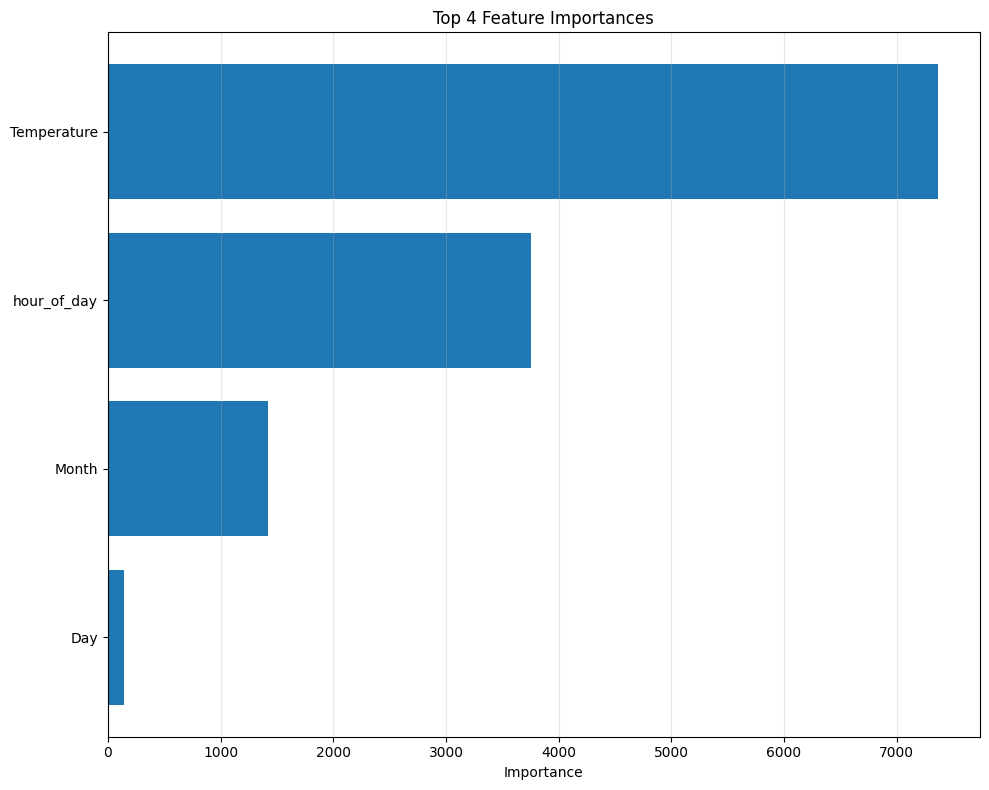

,feature,importance
3,Temperature,7370.225406
2,hour_of_day,3750.332695
0,Month,1422.400016
1,Day,141.428340


In [14]:
# Feature importance works when the estimator exposes feature_importances_ or
# coef_. The fitted Ridge step exposes coefficients, so this example is fast
# and directly tied to the regression model above.
importance_frame = plot_feature_importance(
    regressor.named_steps["model"],
    feature_names=X_train_reg.columns.tolist(),
    top_n=4,
)

importance_frame.head()

## 8. Auto-Modeling and Hyperparameter Search

`auto_classifier()` and `auto_regressor()` compare several classical models
inside a time budget. `hyperparameter_search()` wraps grid/random search.

In [15]:
# Use a small real sample of numeric review features so the comparison stays
# fast. auto_classifier() intentionally tries several model families.
auto_X = (
    DataCleaner(reviews[["age", "positive_feedback_count", "rating"]], verbose=False)
    .coerce_numeric(columns=["age", "positive_feedback_count", "rating"], fill_value=0.0)
    .get_cleaned_data()
) # MAna.data keeps numeric coercion and missing-value policy consistent with the earlier preparation.

auto_y = classification_target
auto_sample = auto_X.assign(target=auto_y).sample(
    min(90, len(auto_X)),
    random_state=42,
) # Create a sample of the auto_X DataFrame with a maximum of 90 rows, while ensuring that the sample is representative of the original data. The target variable is added to the sample for use in model training and evaluation. The random_state parameter ensures reproducibility of the sampling process.

auto_X = auto_sample.drop(columns="target")
auto_y = auto_sample["target"]
auto_X_train, auto_X_test, auto_y_train, auto_y_test = train_test_split(
    auto_X,
    auto_y,
    test_size=0.25,
    random_state=42,
    stratify=auto_y,
)

best_classifier, classifier_scores = auto_classifier(
    auto_X_train,
    auto_y_train,
    auto_X_test,
    auto_y_test,
    time_limit=8,
    metric="accuracy",
    n_jobs=1,
    verbose=False,
)

{
    "best_model": type(best_classifier).__name__,
    "scores": classifier_scores,
}

{'best_model': 'RandomForestClassifier',
 'scores': {'best_model_name': 'Random Forest',
  'best_score': 1.0,
  'all_results': {'Logistic Regression': {'cv_mean': 0.9406593406593406,
    'cv_std': 0.054103444505895264,
    'test_score': 0.9565217391304348,
    'model': LogisticRegression(max_iter=1000, random_state=42)},
   'Random Forest': {'cv_mean': 0.9571428571428571,
    'cv_std': 0.05714285714285716,
    'test_score': 1.0,
    'model': RandomForestClassifier(n_jobs=1, random_state=42)},
   'Gradient Boosting': {'cv_mean': 0.9549450549450551,
    'cv_std': 0.036841878273055385,
    'test_score': 0.9565217391304348,
    'model': GradientBoostingClassifier(random_state=42)},
   'SVM': {'cv_mean': 0.8065934065934066,
    'cv_std': 0.032856959093903404,
    'test_score': 0.782608695652174,
    'model': SVC(probability=True, random_state=42)},
   'Naive Bayes': {'cv_mean': 0.9714285714285715,
    'cv_std': 0.03499271061118824,
    'test_score': 0.9565217391304348,
    'model': Gaussian

In [16]:
auto_reg_sample = electricity_modeling.sample(120, random_state=7)
auto_reg_X = auto_reg_sample[["Month", "Day", "hour_of_day", "Temperature"]]
auto_reg_y = auto_reg_sample["Demand"]

auto_reg_X_train, auto_reg_X_test, auto_reg_y_train, auto_reg_y_test = train_test_split(
    auto_reg_X,
    auto_reg_y,
    test_size=0.25,
    random_state=42,
)

best_regressor, regressor_scores = auto_regressor(
    auto_reg_X_train,
    auto_reg_y_train,
    auto_reg_X_test,
    auto_reg_y_test,
    time_limit=8,
    metric="r2",
    n_jobs=1,
    verbose=False,
)

{
    "best_model": type(best_regressor).__name__,
    "scores": regressor_scores,
}

{'best_model': 'RandomForestRegressor',
 'scores': {'best_model_name': 'Random Forest',
  'best_score': 0.7474708323403882,
  'all_results': {'Linear Regression': {'cv_mean': 0.19013144008345656,
    'cv_std': 0.2176555289021372,
    'test_score': 0.3939322773449193,
    'model': LinearRegression(n_jobs=1)},
   'Ridge': {'cv_mean': 0.1901845501434095,
    'cv_std': 0.21757476596079464,
    'test_score': 0.39387573641075324,
    'model': Ridge(random_state=42)},
   'Lasso': {'cv_mean': 0.19014604045940414,
    'cv_std': 0.21763854419911152,
    'test_score': 0.39392653182681847,
    'model': Lasso(random_state=42)},
   'Random Forest': {'cv_mean': 0.6079521015404735,
    'cv_std': 0.10142069767030527,
    'test_score': 0.7474708323403882,
    'model': RandomForestRegressor(n_jobs=1, random_state=42)},
   'Gradient Boosting': {'cv_mean': 0.5243108050284754,
    'cv_std': 0.19858286564666644,
    'test_score': 0.7416664434565112,
    'model': GradientBoostingRegressor(random_state=42)},
 

In [17]:
# hyperparameter_search() returns a fitted search object.
best_tuned_classifier, search_results = hyperparameter_search(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    param_grid={"C": [0.1, 1.0, 3.0]},
    X=auto_X_train,
    y=auto_y_train,
    search_type="grid",
    cv=3,
    scoring="accuracy",
    n_jobs=1,
    verbose=0,
) # Perform hyperparameter search on a Logistic Regression model using the hyperparameter_search function. The search is conducted over a grid of values for the regularization parameter C, with 3-fold cross-validation and accuracy as the scoring metric. The function returns the best fitted classifier and the search results, which include the best parameters and best score.

{
    "best_model": type(best_tuned_classifier).__name__,
    "best_params": search_results["best_params"],
    "best_score": search_results["best_score"],
}

Starting grid search...

[OK] Search complete!
  Best score: 0.9407
  Best params: {'C': 3.0}


{'best_model': 'LogisticRegression',
 'best_params': {'C': 3.0},
 'best_score': 0.9407114624505929}

## 9. Model Registry and Sklearn Persistence

The registry stores model files with metadata. The standalone sklearn helpers
are useful for simple one-model save/load workflows.

In [18]:
with tempfile.TemporaryDirectory() as registry_dir:
    registry = ModelRegistry(base_dir=registry_dir)
    model_path = registry.save_model(
        regressor,
        model_name="electricity_ridge",
        version="1",
        framework="sklearn",
        task_type="regression",
        metrics={"r2": float(regression_metrics["r2"]), "rmse": float(regression_metrics["rmse"])},
        hyperparameters={"alpha": 1.0},
        feature_names=regression_features.columns.tolist(),
        tags=["electricity", "regression", "demo"],
        description="Ridge baseline for electricity demand.",
    ) # Save the trained regression model to a temporary model registry using the ModelRegistry class. The model is saved with metadata including its name, version, framework, task type, evaluation metrics, hyperparameters, feature names, tags, and a description. The model path is returned for later use.

    loaded_regressor = registry.load_model("electricity_ridge", version="1")
    registry_table = registry.list_models()
    comparison = registry.compare_models("electricity_ridge")

{
    "model_path": model_path,
    "loaded_prediction": loaded_regressor.predict(X_test_reg.head(2)).tolist(),
    "registry_table": registry_table,
    "comparison": comparison,
}

[OK] Model saved: electricity_ridge v1
  Path: C:\Users\LAPTOP~1\AppData\Local\Temp\tmp2vgx388i\electricity_ridge\1\model
  Framework: sklearn
  Metrics: {'r2': 0.4809912879358248, 'rmse': 8520.523741510924}
[OK] Model loaded: electricity_ridge v1
  Framework: sklearn
  Metrics: {'r2': 0.4809912879358248, 'rmse': 8520.523741510924}


{'model_path': 'C:\\Users\\LAPTOP~1\\AppData\\Local\\Temp\\tmp2vgx388i\\electricity_ridge\\1\\model',
 'loaded_prediction': [63041.33103880056, 53628.7155315719],
 'registry_table':           model_name version framework   task_type  \
 0  electricity_ridge       1   sklearn  regression   
 
                    created_at  metric_r2  metric_rmse  
 0  2026-07-22T23:03:27.270804   0.480991  8520.523742  ,
 'comparison':   version                  created_at        r2         rmse
 0       1  2026-07-22T23:03:27.270804  0.480991  8520.523742}

In [19]:
with tempfile.TemporaryDirectory() as model_dir:
    model_file = str(Path(model_dir) / "ridge_model")
    save_sklearn_model(regressor, model_file)
    reloaded = load_sklearn_model(model_file + ".pkl")
    sklearn_roundtrip = reloaded.predict(X_test_reg.head(3)).tolist()

sklearn_roundtrip

[OK] Saved model to C:\Users\LAPTOP~1\AppData\Local\Temp\tmpsy4osesd\ridge_model.pkl
[OK] Loaded model from C:\Users\LAPTOP~1\AppData\Local\Temp\tmpsy4osesd\ridge_model.pkl


[63041.33103880056, 53628.7155315719, 60369.80141671581]

## 10. Modeling Visualizations

MAna's modeling visualizations are separate from the metric functions. Use
them when you want a report figure without re-writing plotting code.

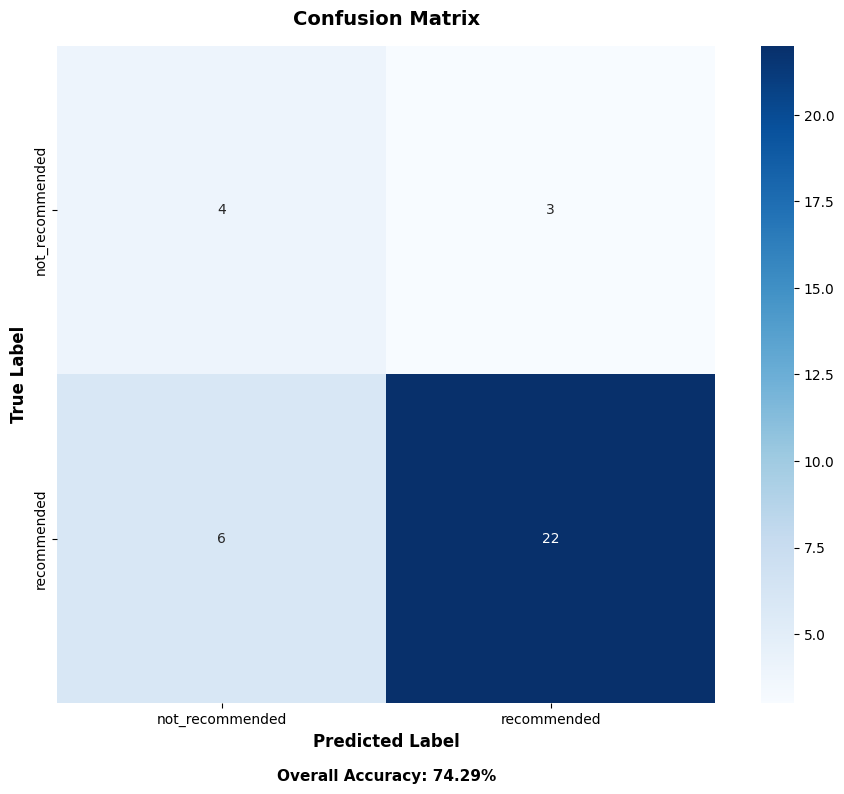

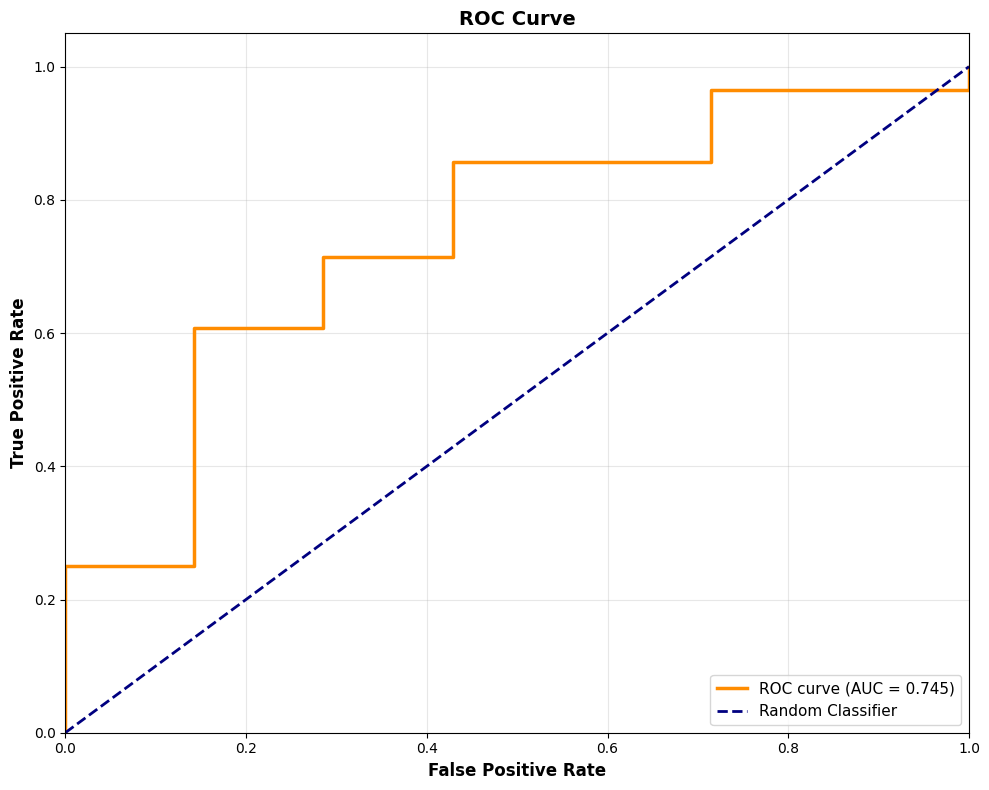

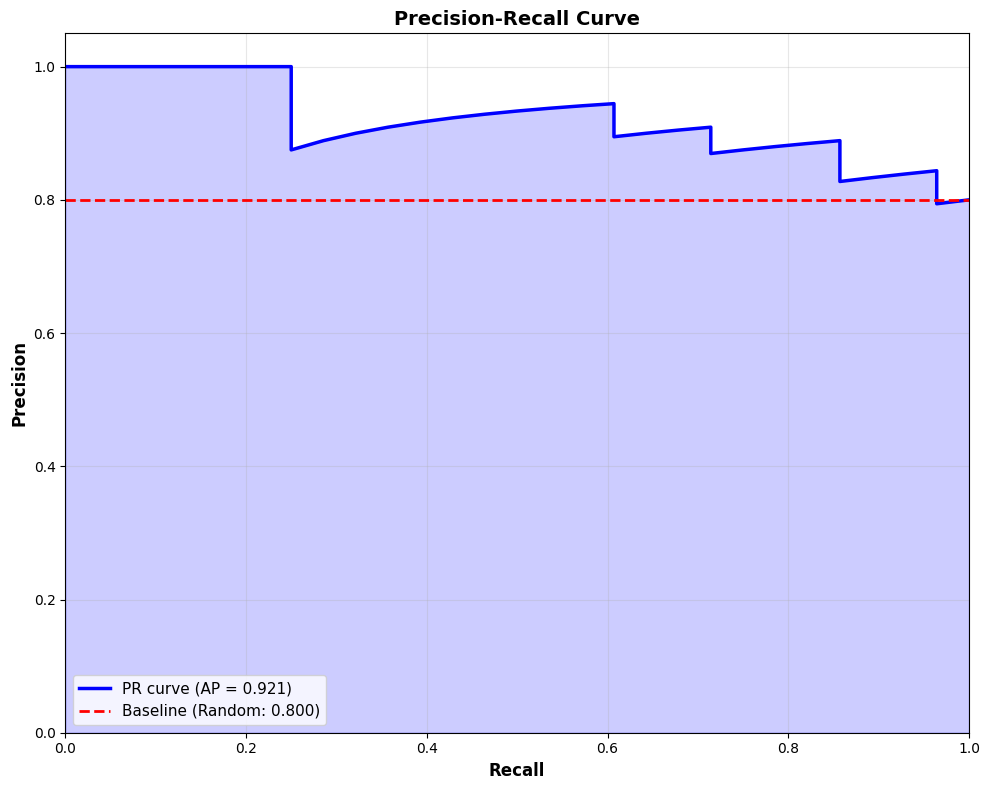

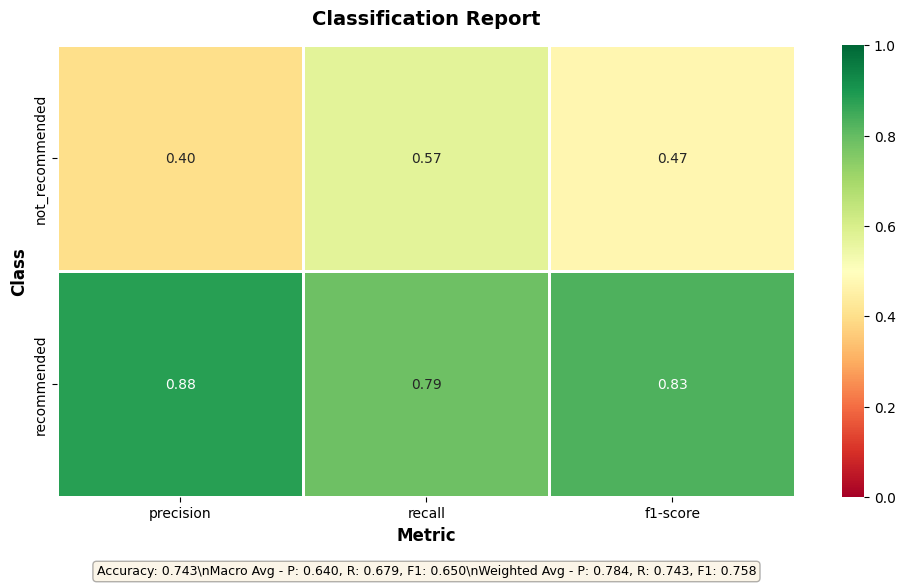

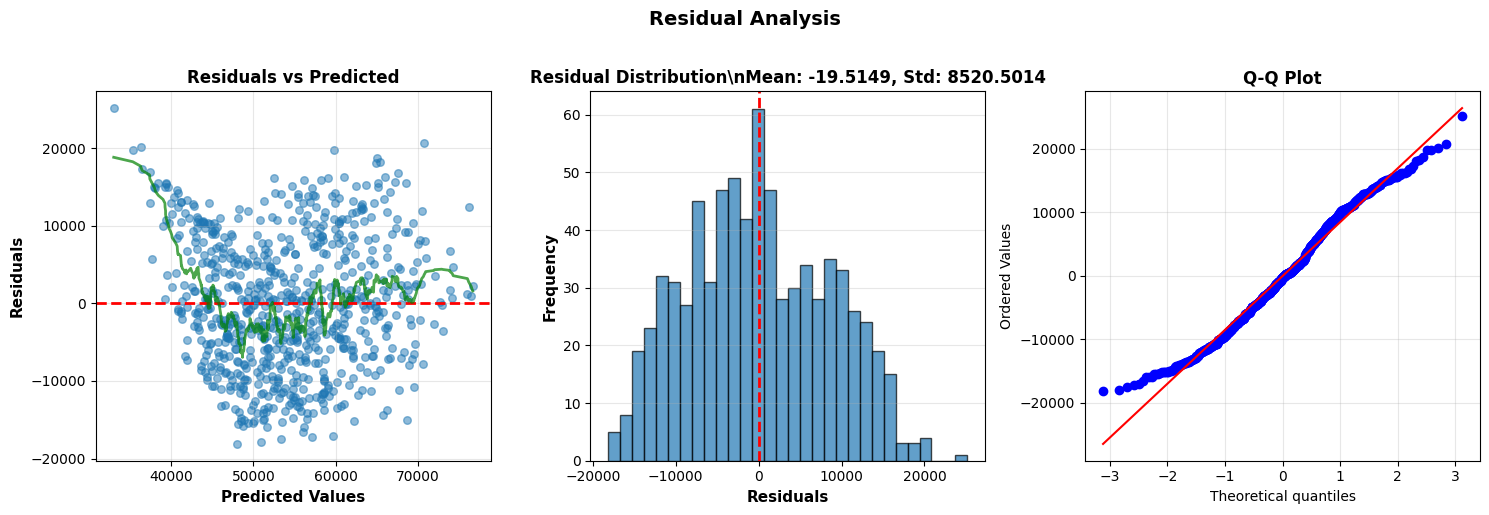

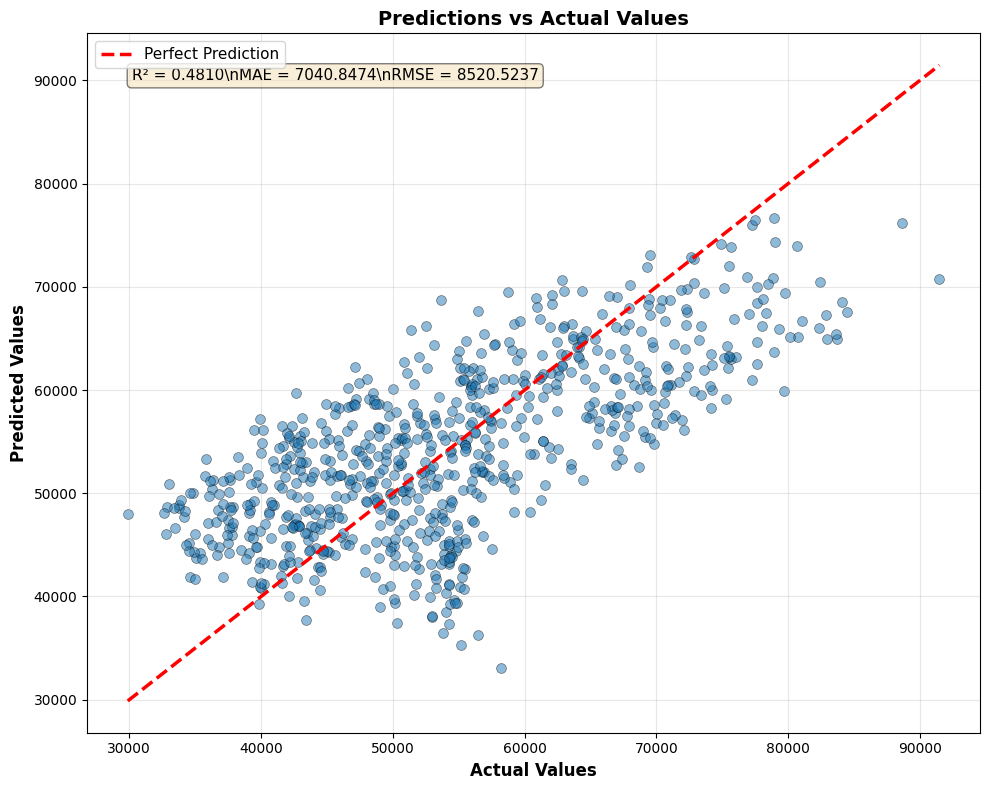

'Created and closed classification/regression diagnostic figures.'

In [20]:
import matplotlib.pyplot as plt

y_pred_cls = classifier.predict(X_test_cls)
y_prob_cls = classifier.predict_proba(X_test_cls)[:, 1]
y_pred_reg = regressor.predict(X_test_reg)

# These calls create figures in an interactive notebook. During automated
# validation we close them immediately so the saved notebook remains clean.
mana_confusion_matrix(y_test_cls, y_pred_cls, labels=["not_recommended", "recommended"])
mana_roc_curve(y_test_cls, y_prob_cls)
mana_precision_recall_curve(y_test_cls, y_prob_cls)
plot_classification_report(y_test_cls, y_pred_cls, labels=["not_recommended", "recommended"])
plot_residuals(y_test_reg, y_pred_reg)
plot_predictions_vs_actual(y_test_reg, y_pred_reg)
plt.close("all")

"Created and closed classification/regression diagnostic figures."

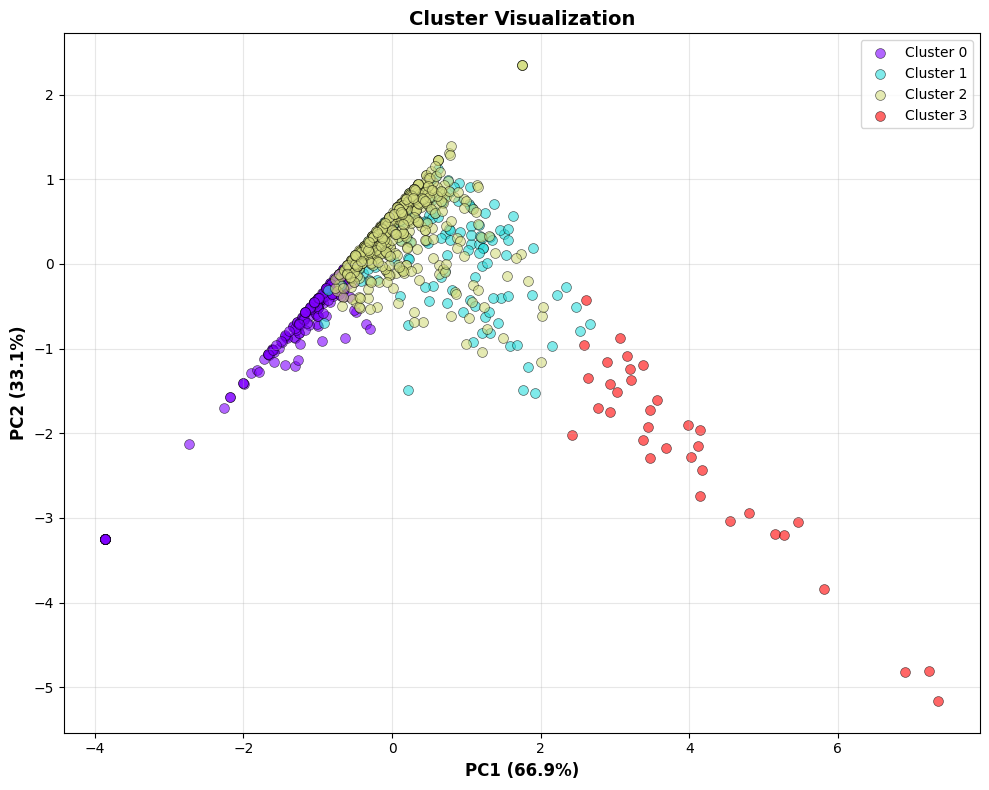

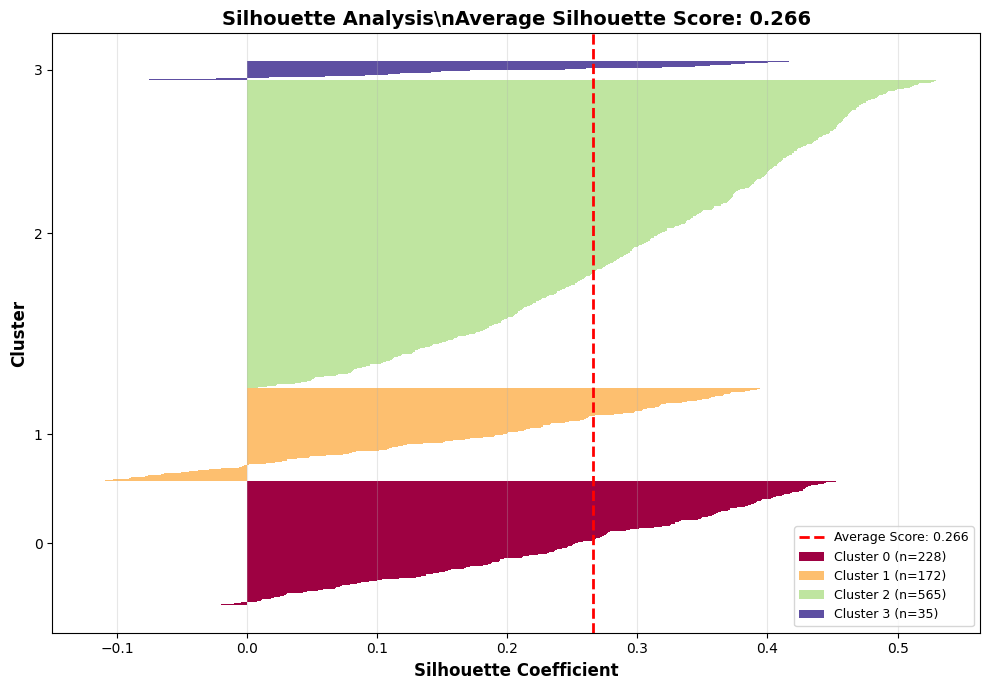

c:\Users\LAPTOP WORLD\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LAPTOP WORLD\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LAPTOP WORLD\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\LAPTOP WORLD\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known

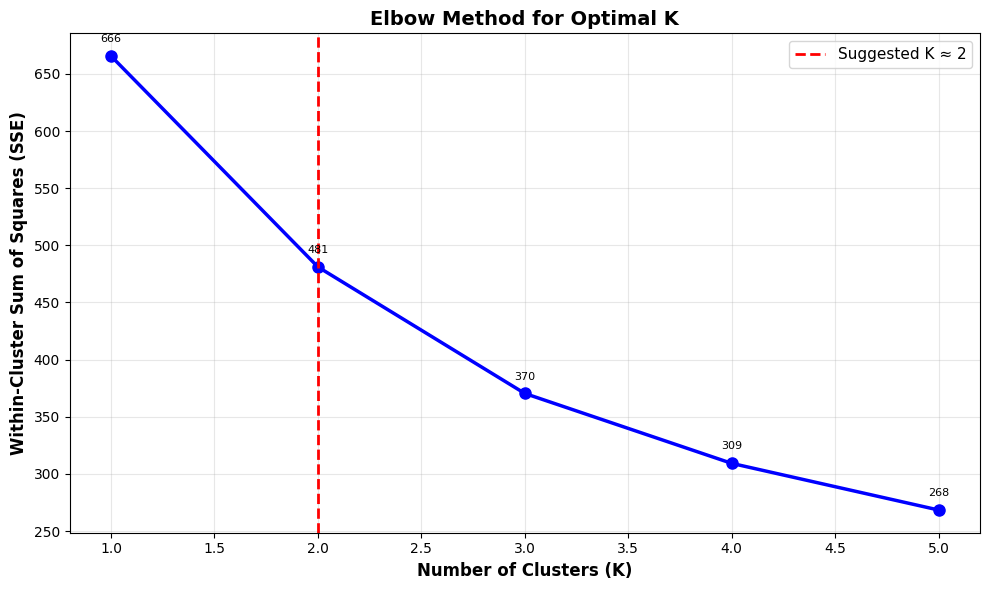

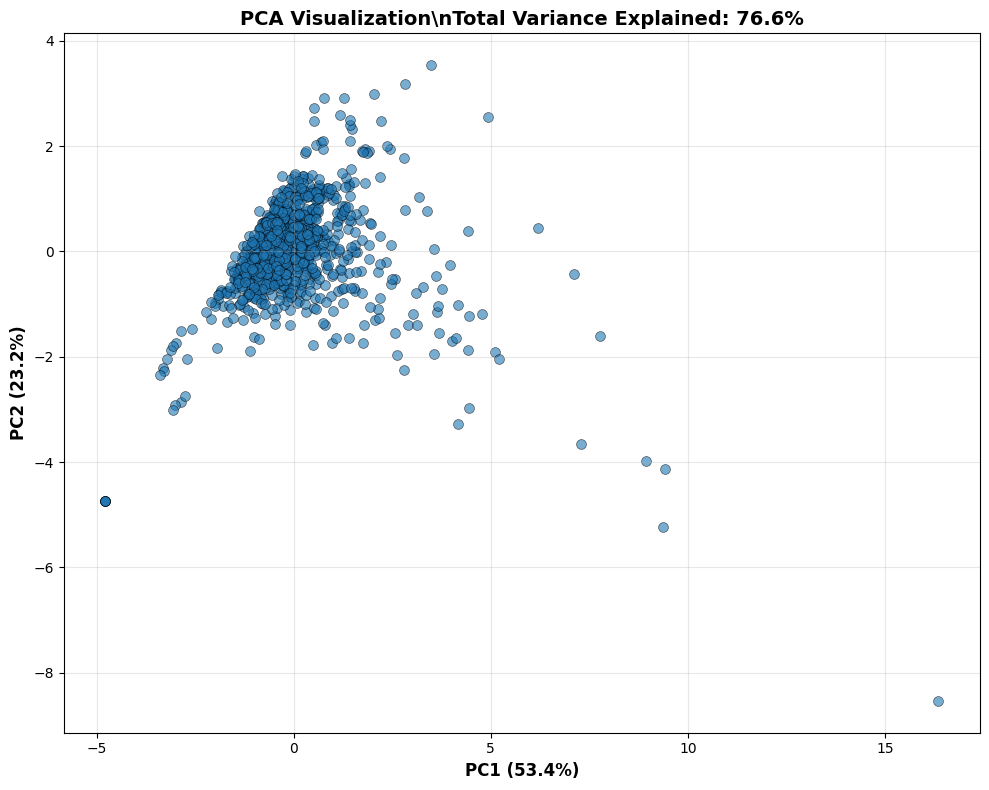

'Created and closed clustering/PCA diagnostic figures.'

In [21]:
import matplotlib.pyplot as plt

plot_cluster(cluster_matrix[:, :2], cluster_model.labels_, method="2d")
silhouette(cluster_matrix, cluster_model.labels_)
plot_elbow(cluster_matrix[:250], max_k=5)
plot_pca(pd.DataFrame(cluster_matrix, columns=movie_cluster_features.columns), n_components=2)
plt.close("all")

"Created and closed clustering/PCA diagnostic figures."

## 11. Keras Utilities

Keras helpers are optional and guarded. They provide standard callbacks and
save/load patterns for TensorFlow/Keras models.

In [22]:
RUN_KERAS_DEMO = False

if RUN_KERAS_DEMO and TENSORFLOW_AVAILABLE:
    callbacks = get_training_callbacks(
        model_name="demo_keras_model",
        early_stop_patience=3,
        reduce_lr_patience=2,
        save_checkpoints=False,
        tensorboard=False,
    )
    keras_demo = [type(callback).__name__ for callback in callbacks]
else:
    keras_demo = (
        "Skipped by default. Set RUN_KERAS_DEMO = True when you want to "
        "instantiate TensorFlow/Keras callbacks in this notebook."
    )

keras_demo

'Skipped by default. Set RUN_KERAS_DEMO = True when you want to instantiate TensorFlow/Keras callbacks in this notebook.'

## 12. PyTorch Utilities

The PyTorch utilities include device selection, seed control, dataloaders,
simple model classes, parameter counting, freezing, and metric helpers.

In [23]:
if TORCH_AVAILABLE:
    import torch

    set_seed(42)
    device = get_device(prefer_gpu=False)
    torch_model = SimpleClassifier(input_size=3, hidden_sizes=[8], output_size=1, dropout=0.1)
    parameter_count = count_parameters(torch_model)

    X_tensor = auto_X_train.to_numpy(dtype="float32")
    y_tensor = auto_y_train.to_numpy(dtype="float32")
    train_loader = create_data_loaders(X_tensor, y_tensor, batch_size=16)
    batch_features, batch_targets = next(iter(train_loader))

    with torch.no_grad():
        outputs = torch_model(batch_features)
    torch_accuracy = accuracy_pytorch(outputs, batch_targets)
    torch_f1 = f1_score_pytorch(outputs, batch_targets)

    freeze_layers(torch_model)
    frozen_trainable = count_parameters(torch_model, trainable_only=True)
    unfreeze_layers(torch_model)
    unfrozen_trainable = count_parameters(torch_model, trainable_only=True)

    torch_demo = {
        "device": str(device),
        "parameters": parameter_count,
        "batch_shapes": (tuple(batch_features.shape), tuple(batch_targets.shape)),
        "accuracy": torch_accuracy,
        "f1": torch_f1,
        "trainable_after_freeze": frozen_trainable,
        "trainable_after_unfreeze": unfrozen_trainable,
    }
else:
    torch_demo = "Skipped: PyTorch is not installed."

torch_demo

[OK] Set random seed to 42
[OK] Using CPU
[OK] Froze all layers
[OK] Unfroze all layers


{'device': 'cpu',
 'parameters': 41,
 'batch_shapes': ((16, 3), (16,)),
 'accuracy': 13.0,
 'f1': 0.8965517282485962,
 'trainable_after_freeze': 0,
 'trainable_after_unfreeze': 41}

## 13. Practical Recipe

For modeling work, use MAna like this:

1. Prepare data with `MAna.data`, then keep modeling-specific preprocessing
   close to the model.
2. Evaluate classification, regression, and clustering with task-specific
   reports.
3. Use cross-validation before trusting a single split.
4. Compare classical models quickly with `auto_classifier()` or
   `auto_regressor()`.
5. Tune only after the baseline is working.
6. Register or save models with metrics, features, and tags.
7. Use Keras/PyTorch helpers when the problem justifies deep learning.

That is the shape of `MAna.modeling`: practical baselines, honest evaluation,
and enough lifecycle tooling to remember what a model actually was.